# DNA Methodology

The DNA method is not perfect, in fact, it may overlook many aspect of a mobile game.

In [1]:
import pandas as pd

df_path = "../data/cleaned/cleaned_data"
df = pd.read_parquet(df_path)

In [2]:
df.head()

,game_id,player_id,event_date,cumulative_iap_revenue,cumulative_purchases,cumulative_session_count,cumulative_time_spent,iap_revenue,num_purchases,session_count,time_spent,registration_date,country_isocode2,operating_system,origin_category,days_since_registration
0,Game A,18338764,17742.0,0.0,0.0,1.0,3.0,0.0,0.0,1.0,3,17742.0,US,Android,Paid,0.0
1,Game A,18338764,17801.0,0.0,0.0,16.0,138.0,0.0,0.0,4.0,3,17784.0,CA,iOS,Organic,17.0
2,Game A,18338810,17852.0,0.0,0.0,1.0,36.0,0.0,0.0,3.0,39,17852.0,US,iOS,Paid,0.0
3,Game A,18338870,17663.0,0.0,0.0,17.0,261.0,0.0,0.0,5.0,48,17661.0,IT,Android,Network Users,2.0
4,Game A,18338870,17805.0,0.0,0.0,22.0,334.0,0.0,0.0,4.0,4,17768.0,US,Android,Organic,37.0


## Retention rate

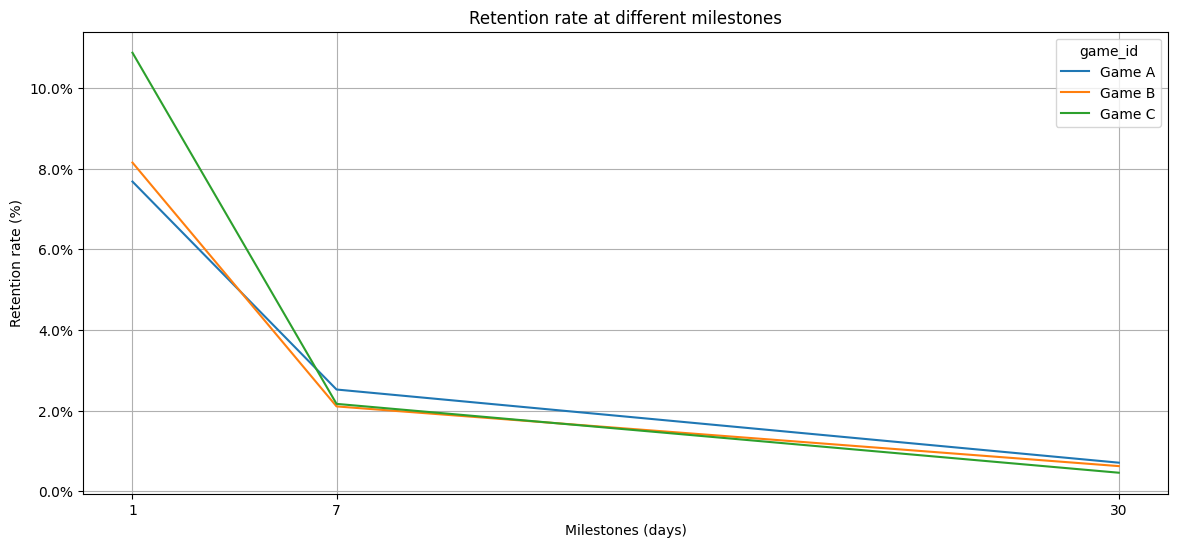

In [3]:
periods = [1, 7, 30]
elapsed_day_freq = df.groupby(by="game_id")["days_since_registration"] \
                    .value_counts(normalize=True).apply(lambda x: x*100) \
                    .reset_index(name="frequency")
day_retention = elapsed_day_freq[elapsed_day_freq["days_since_registration"].isin(periods)]
day_retention

# retention plot
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(
    data=day_retention,
    x="days_since_registration",
    y="frequency",
    hue="game_id")
ax.set(
    xlabel="Milestones (days)",
    ylabel="Retention rate (%)", 
    title="Retention rate at different milestones", 
    xticks=periods)
ax.grid(True)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.show()

- For any products, it is essential to maintain good retention rates over long periods of time. Game C may have a good day1 retention, but it can still struggle to keep up after 30 days. 

## Purchases and revenue

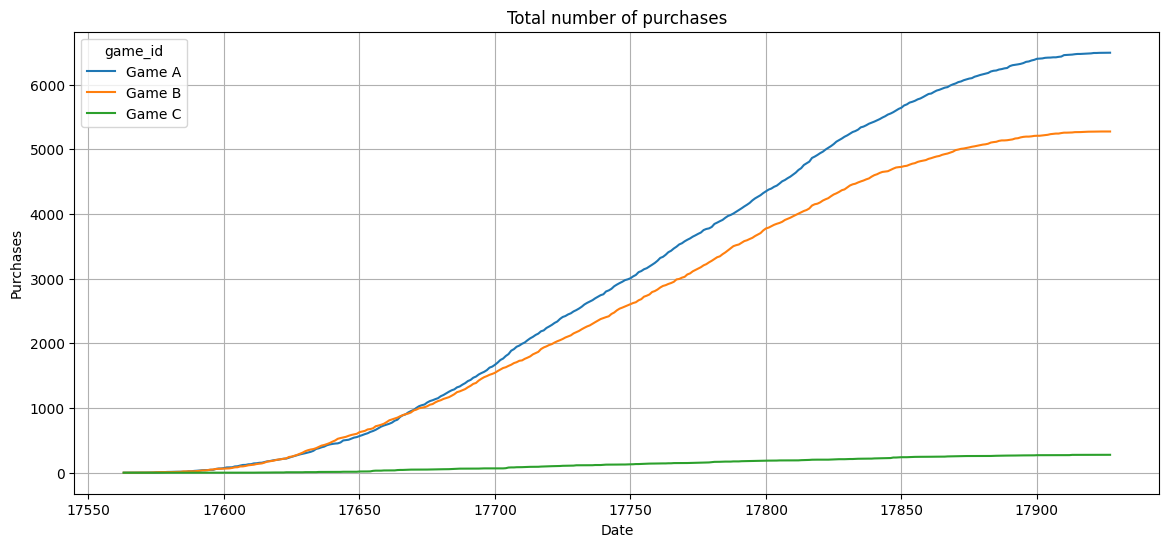

In [4]:
game_daily_purchases = df.groupby(by=["game_id", "event_date"])["num_purchases"].sum() \
                            .reset_index(name="purchases") \
                            .sort_values(by=["game_id", "event_date"])
game_daily_purchases["cumsum_purchases"] = game_daily_purchases.groupby(by="game_id")["purchases"].cumsum()
game_daily_purchases

# plot total number of purchases
fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(
    data=game_daily_purchases,
    x="event_date",
    y="cumsum_purchases",
    hue="game_id")
ax.set(
    xlabel="Date",
    ylabel="Purchases", 
    title="Total number of purchases"
    )
ax.grid(True)
plt.show()

- From its DNA, game B should have the lowest potential, but it managed to encourage players to make in-game purchases, just second to game A>

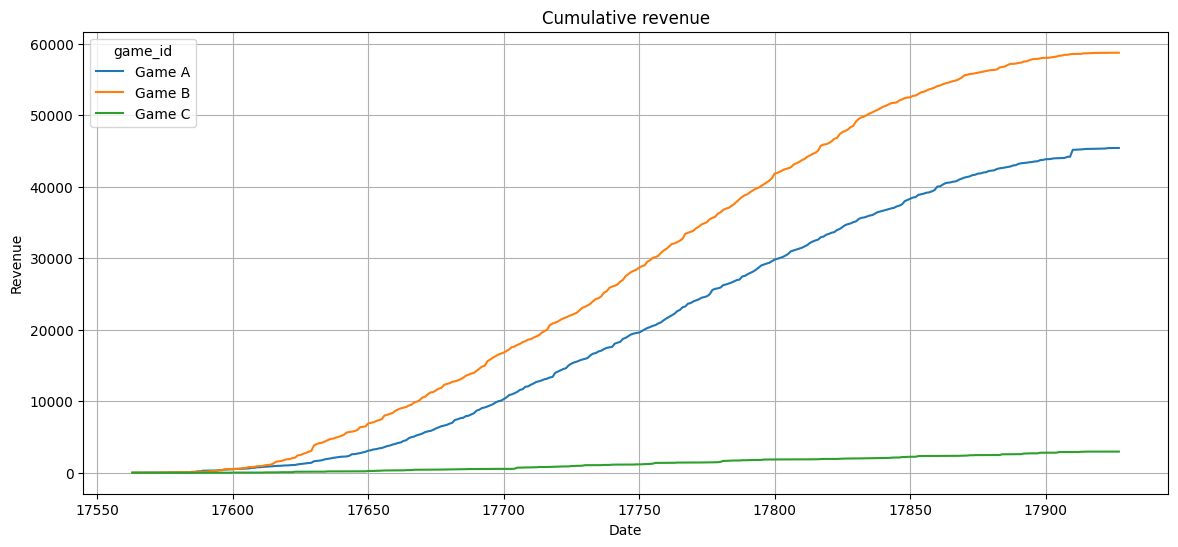

In [5]:
group_revenue = df.groupby(by=["game_id", "event_date"])["iap_revenue"].sum() \
                    .reset_index(name="revenue") \
                    .sort_values(by=["game_id", "event_date"])
group_revenue["cumsum_revenue"] = group_revenue.groupby(by=["game_id"])["revenue"].cumsum()
group_revenue

# plot cumulative revenue
fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(
    data=group_revenue,
    x="event_date",
    y="cumsum_revenue",
    hue="game_id")
ax.set(
    xlabel="Date",
    ylabel="Revenue", 
    title="Cumulative revenue"
    )
ax.grid(True)
plt.show()

- And here, game B actually generated the most revenue!

## Origin categories

In [6]:
game_origin_categories = df.groupby(by=["game_id"])["origin_category"] \
                            .value_counts(normalize=True) \
                            .apply(lambda x: round(x*100, 2)) \
                            .reset_index(name="registration_num")
                                
game_origin_categories_pivot = game_origin_categories.set_index("origin_category") \
                                .pivot(columns="game_id", values="registration_num")

game_origin_categories_pivot

game_id,Game A,Game B,Game C
origin_category,,,
Network Users,13.86,13.92,13.96
Organic,54.98,54.96,54.88
Paid,23.99,23.91,24.02
X-Promo,7.18,7.21,7.14


***NB:***

Players acquired organically have genuine interest toward the game and tend to be more patient and stick around longer.

Paid players generally have little interest in the game so it's hard for them to stay. However, companies have their information and know of their behavior (companies managed to attract them through paid promotions), so it is easier to make appropriate sales to encourage spending.

***POSSIBLE FLAW:***

One flaw of the DNA method is to put the same weight on all new players and assume that every player behaves the same when it comes to starting a new game. In fact, players acquired from different channels behave differently due to their various expectations.

***SUGGESTION:*** 

Acquire the players' method of acquisition and plot the DNAs for each category of players.